# ВКР: Предсказание популярности музыкального трека
## Level 4: Текстовый анализ лирики (Genius API)

**Вход:** `dataset_clean.csv`  
**Источник лирики:** Genius API (lyricsgenius)  
**Признаки:** SBERT (384) + VADER (4) + метрики (9) = 397  
**Выход:** `text_features.csv`, `level4_results.csv`  

**Кеширование:** каждые 500 треков. 

---
## 1. Импорт

In [1]:
import sys
!{sys.executable} -m pip install lyricsgenius


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, re, time, json, joblib
from collections import Counter
from tqdm import tqdm
import lyricsgenius
import warnings; warnings.filterwarnings('ignore')

from sentence_transformers import SentenceTransformer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
print('OK')


OK


In [3]:
df = pd.read_csv('dataset_clean.csv')
df['explicit'] = df['explicit'].astype(int)
target = 'popularity'
print(f'Датасет: {len(df):,} треков')

Датасет: 81,207 треков


---
## 2. Genius API: настройка

Получите токен: https://genius.com/api-clients

In [4]:
GENIUS_TOKEN = '1HyYph4_uHS7eIwPLPLQN3L47M5BjbNRhr-YsoAaUpcdR3itBml-wpo40Pv8651D'

genius = lyricsgenius.Genius(
    GENIUS_TOKEN,
    timeout=15,
    retries=2,
    verbose=False,
    remove_section_headers=True,
    skip_non_songs=True,
)
genius.excluded_terms = ['(Remix)', '(Live)', '(Demo)', '(Instrumental)']

try:
    song = genius.search_song('Billie Jean', 'Michael Jackson')
    if song and song.lyrics and len(song.lyrics) > 50:
        print(f'Genius API работает: {len(song.lyrics)} символов')
    else:
        print('Текст не найден')
except Exception as e:
    print(f'Ошибка: {e}')

Genius API работает: 2914 символов


In [5]:
def normalize_name(name):
    if not isinstance(name, str): return ''
    name = re.sub(r'\s*[\(\[].*?[\)\]]', '', name)
    name = re.sub(r'\s*-\s*(Remastered|Remaster|Deluxe|Radio Edit|Single Version|Bonus Track|Anniversary).*', '', name, flags=re.IGNORECASE)
    name = re.sub(r'\s*feat\.?\s+.*', '', name, flags=re.IGNORECASE)
    name = re.sub(r'\s*ft\.?\s+.*', '', name, flags=re.IGNORECASE)
    return name.strip()

def first_artist(name):
    if not isinstance(name, str): return ''
    return re.split(r'[,;&]|\sfeat\.?\s|\sft\.?\s|\sx\s|\svs\.?\s', name, flags=re.IGNORECASE)[0].strip()

def clean_genius_lyrics(text):
    if not text: return ''
    lines = text.split('\n')
    if lines and 'Lyrics' in lines[0]:
        lines = lines[1:]
    text = '\n'.join(lines)
    text = re.sub(r'\d*Embed$', '', text).strip()
    text = text.replace('You might also like', '').strip()
    text = re.sub(r'See .+ live.*?Get tickets as low as \$\d+', '', text).strip()
    return text

def fetch_genius(artist, title):
    queries = [
        (first_artist(artist), title),
        (first_artist(artist), normalize_name(title)),
    ]
    for a, t in queries:
        if not a or not t or len(t) < 2: continue
        try:
            song = genius.search_song(t, a)
            if song and song.lyrics:
                cleaned = clean_genius_lyrics(song.lyrics)
                if len(cleaned) > 50:
                    return cleaned
        except: pass
    return None

print('Функции готовы')

Функции готовы


---
## 3. Загрузка кеша и скачивание

In [6]:
!{sys.executable} -m pip install ijson


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
LYRICS_CACHE = 'genius_lyrics_cache.json'

lyrics_dict = {}
if os.path.exists(LYRICS_CACHE):
    import ijson
    try:
        with open(LYRICS_CACHE, 'r', encoding='utf-8') as f:
            for key, value in ijson.kvitems(f, ''):
                lyrics_dict[int(key)] = value
        print(f'Кеш загружен: {len(lyrics_dict):,} записей')
    except:

        import gc
        gc.collect()
        with open(LYRICS_CACHE, 'r', encoding='utf-8') as f:
            content = f.read()
        lyrics_dict = {int(k): v for k, v in json.loads(content).items()}
        del content
        gc.collect()
        print(f'Кеш загружен (fallback): {len(lyrics_dict):,} записей')

Кеш загружен: 81,207 записей


In [8]:
to_fetch = []
for idx in range(len(df)):
    if idx not in lyrics_dict:
        to_fetch.append(idx)
    elif lyrics_dict[idx] is None or lyrics_dict[idx] == '':
        to_fetch.append(idx)

print(f'К запросу через Genius: {len(to_fetch):,}')
print(f'Примерное время: {len(to_fetch)*2/3600:.1f} часов')

К запросу через Genius: 17,085
Примерное время: 9.5 часов


In [9]:
new_found = 0; new_fail = 0
save_every = 500

for i, idx in enumerate(tqdm(to_fetch, desc='Genius')):
    if idx >= len(df): continue
    row = df.iloc[idx]
    text = fetch_genius(str(row.get('artists', '')), str(row.get('track_name', '')))
    if text:
        lyrics_dict[idx] = text
        new_found += 1
    else:
        lyrics_dict[idx] = None
        new_fail += 1
    if (i + 1) % save_every == 0:
        cache_save = {str(k): v for k, v in lyrics_dict.items()}
        with open(LYRICS_CACHE, 'w', encoding='utf-8') as f:
            json.dump(cache_save, f, ensure_ascii=False)
        total_found = sum(1 for v in lyrics_dict.values() if v is not None and v != '')
        tqdm.write(f'  [{i+1}/{len(to_fetch)}] +{new_found:,} новых, всего: {total_found:,}')

cache_save = {str(k): v for k, v in lyrics_dict.items()}
with open(LYRICS_CACHE, 'w', encoding='utf-8') as f:
    json.dump(cache_save, f, ensure_ascii=False)

total_found = sum(1 for v in lyrics_dict.values() if v is not None and v != '')
print(f'\nГотово: +{new_found:,} новых, +{new_fail:,} не найдено')
print(f'ИТОГО: {total_found:,} текстов из {len(df):,} ({total_found/len(df)*100:.1f}%)')

Genius:   3%|███▌                                                                                                                       | 500/17085 [15:30<25:22:38,  5.51s/it]

  [500/17085] +0 новых, всего: 64,122


Genius:   6%|███████▏                                                                                                                  | 1000/17085 [30:26<15:24:41,  3.45s/it]

  [1000/17085] +0 новых, всего: 64,122


Genius:   9%|██████████▋                                                                                                               | 1500/17085 [45:12<19:06:05,  4.41s/it]

...

  [16500/17085] +4,054 новых, всего: 68,176


Genius: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 17000/17085 [10:08:43<04:18,  3.04s/it]

  [17000/17085] +4,054 новых, всего: 68,176


Genius: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 17085/17085 [10:10:16<00:00,  2.14s/it]



Готово: +4,054 новых, +13,031 не найдено
ИТОГО: 68,176 текстов из 81,207 (84.0%)


---
## 4. Извлечение текстовых признаков

In [10]:
text_indices = sorted([idx for idx, v in lyrics_dict.items()
                       if v is not None and v != '' and len(v) > 50 and idx < len(df)])
df_text = df.iloc[text_indices].copy().reset_index(drop=True)
texts = [lyrics_dict[idx] for idx in text_indices]

print(f'Треков с текстом: {len(df_text):,}')
print(f'Popularity: min={df_text[target].min()}, max={df_text[target].max()}, mean={df_text[target].mean():.1f}, median={df_text[target].median():.0f}')
print(f'Средняя длина текста: {np.mean([len(t) for t in texts]):.0f} символов')

Треков с текстом: 68,176
Popularity: min=3, max=100, mean=39.9, median=39
Средняя длина текста: 14727 символов


In [11]:
print('Загружаем SBERT...')
sbert = SentenceTransformer('all-MiniLM-L6-v2')
vader = SentimentIntensityAnalyzer()
print('SBERT и VADER загружены')

print(f'\nВычисляем SBERT эмбеддинги для {len(texts):,} текстов...')
texts_truncated = [t[:1000] if isinstance(t, str) else '' for t in texts]
sbert_embeddings = sbert.encode(texts_truncated, show_progress_bar=True, batch_size=128)
print(f'SBERT: {sbert_embeddings.shape}')

Загружаем SBERT...
SBERT и VADER загружены

Вычисляем SBERT эмбеддинги для 68,176 текстов...


Batches: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 533/533 [03:50<00:00,  2.31it/s]


SBERT: (68176, 384)


In [12]:
def text_metrics(text):
    if not isinstance(text, str) or len(text) < 10:
        return {f: 0 for f in ['word_count','unique_words','lexical_diversity','line_count',
                                'avg_word_length','avg_line_length','max_line_repeat','avg_line_repeat',
                                'chars_per_word','vader_pos','vader_neg','vader_neu','vader_compound']}
    words = text.lower().split()
    lines = [l.strip() for l in text.split('\n') if l.strip()]
    unique = set(words)
    line_counts = Counter(lines)
    vs = vader.polarity_scores(text[:5000])
    return {
        'word_count': len(words), 'unique_words': len(unique),
        'lexical_diversity': len(unique)/max(len(words),1),
        'line_count': len(lines), 'avg_word_length': np.mean([len(w) for w in words]) if words else 0,
        'avg_line_length': np.mean([len(l) for l in lines]) if lines else 0,
        'max_line_repeat': max(line_counts.values()) if line_counts else 0,
        'avg_line_repeat': np.mean(list(line_counts.values())) if line_counts else 0,
        'chars_per_word': sum(len(w) for w in words)/max(len(words),1),
        'vader_pos': vs['pos'], 'vader_neg': vs['neg'],
        'vader_neu': vs['neu'], 'vader_compound': vs['compound'],
    }

print('Вычисляем метрики и sentiment...')
metrics_list = [text_metrics(t) for t in tqdm(texts, desc='Metrics')]
df_metrics = pd.DataFrame(metrics_list)

sbert_cols = [f'sbert_{i}' for i in range(sbert_embeddings.shape[1])]
df_sbert = pd.DataFrame(sbert_embeddings, columns=sbert_cols)
df_features = pd.concat([df_metrics, df_sbert], axis=1)
df_features['_idx'] = text_indices

print(f'\nТекстовые признаки: {len(df_features):,} треков, {len(df_features.columns)-1} фичей')
print(f'  Sentiment + метрики: {len(df_metrics.columns)}')
print(f'  SBERT: {sbert_embeddings.shape[1]}')

Вычисляем метрики и sentiment...


Metrics: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 68176/68176 [07:22<00:00, 154.20it/s]



Текстовые признаки: 68,176 треков, 397 фичей
  Sentiment + метрики: 13
  SBERT: 384


In [13]:
df_features.to_csv('text_features.csv', index=False)
print(f'Сохранено text_features.csv: {len(df_features):,} треков, {len(df_features.columns)} колонок')

Сохранено text_features.csv: 68,176 треков, 398 колонок


---
## 5. Моделирование

In [14]:
spotify_features = ['danceability','energy','loudness','speechiness','acousticness',
    'instrumentalness','liveness','valence','tempo','duration_ms','key','mode','time_signature','explicit']

text_feature_names = list(df_metrics.columns) + sbert_cols

df_model = df_text[spotify_features + [target]].copy().reset_index(drop=True)
for f in text_feature_names:
    df_model[f] = df_features[f].values

y = df_model[target]
tr, te = train_test_split(np.arange(len(df_model)), test_size=0.2, random_state=42)
threshold = y.iloc[tr].median()
y_te_bin = (y.iloc[te] >= threshold).astype(int)
print(f'Датасет: {len(df_model):,}, Train: {len(tr):,}, Test: {len(te):,}, Порог: {threshold}')

configs = {
    'Spotify (L1)':      spotify_features,
    'Text (L4)':         text_feature_names,
    'Spotify + Text':    spotify_features + text_feature_names,
}

model_types = {
    'Linear Regression': lambda: LinearRegression(),
    'Random Forest': lambda: RandomForestRegressor(n_estimators=300, max_depth=15, min_samples_split=10, min_samples_leaf=5, random_state=42, n_jobs=-1),
    'XGBoost': lambda: XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbosity=0),
    'LightGBM': lambda: LGBMRegressor(n_estimators=300, max_depth=10, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbose=-1),
}

Датасет: 68,176, Train: 54,540, Test: 13,636, Порог: 39.0


In [15]:
results_l4 = {}
print(f'{"Config":25s} | {"Model":20s} | {"MAE":>7s} | {"RMSE":>7s} | {"R²":>7s} | {"AUC":>7s}')
print('=' * 100)
for cname, flist in configs.items():
    Xtr, Xte = df_model[flist].iloc[tr], df_model[flist].iloc[te]
    sc = StandardScaler(); Xtr_s, Xte_s = sc.fit_transform(Xtr), sc.transform(Xte)
    for mname, mfn in model_types.items():
        m = mfn(); m.fit(Xtr_s, y.iloc[tr]); yp = m.predict(Xte_s)
        mae=mean_absolute_error(y.iloc[te],yp); rmse=np.sqrt(mean_squared_error(y.iloc[te],yp))
        r2=r2_score(y.iloc[te],yp); auc=roc_auc_score(y_te_bin,yp)
        results_l4[(cname,mname)]={'MAE':mae,'RMSE':rmse,'R2':r2,'AUC':auc,'model':m,'y_pred':yp}
        print(f'{cname:25s} | {mname:20s} | {mae:7.3f} | {rmse:7.3f} | {r2:7.4f} | {auc:7.4f}')
    print('-' * 100)

Config                    | Model                |     MAE |    RMSE |      R² |     AUC
Spotify (L1)              | Linear Regression    |  13.121 |  15.863 |  0.0807 |  0.6322
Spotify (L1)              | Random Forest        |  12.047 |  14.880 |  0.1911 |  0.7139
Spotify (L1)              | XGBoost              |  11.956 |  14.839 |  0.1955 |  0.7158
Spotify (L1)              | LightGBM             |  11.982 |  14.828 |  0.1967 |  0.7146
----------------------------------------------------------------------------------------------------
Text (L4)                 | Linear Regression    |  11.825 |  14.813 |  0.1984 |  0.7331
Text (L4)                 | Random Forest        |  10.868 |  13.842 |  0.3001 |  0.7875
Text (L4)                 | XGBoost              |  10.761 |  13.835 |  0.3008 |  0.7860
Text (L4)                 | LightGBM             |  11.003 |  13.978 |  0.2862 |  0.7755
--------------------------------------------------------------------------------------------------

In [16]:
cnames = list(configs.keys()); mnames = list(model_types.keys())
best = max(mnames, key=lambda m: np.mean([results_l4[(c,m)]['R2'] for c in cnames]))
print(f'Лучшая модель: {best}\n')
for c in cnames:
    r = results_l4[(c,best)]
    print(f'  {c:25s}: {best} (R²={r["R2"]:.4f}, RMSE={r["RMSE"]:.3f}, MAE={r["MAE"]:.3f}, AUC={r["AUC"]:.4f})')

Лучшая модель: XGBoost

  Spotify (L1)             : XGBoost (R²=0.1955, RMSE=14.839, MAE=11.956, AUC=0.7158)
  Text (L4)                : XGBoost (R²=0.3008, RMSE=13.835, MAE=10.761, AUC=0.7860)
  Spotify + Text           : XGBoost (R²=0.3687, RMSE=13.146, MAE=10.273, AUC=0.8072)


SBERT: 93.6%, Метрики+Sentiment: 6.4%


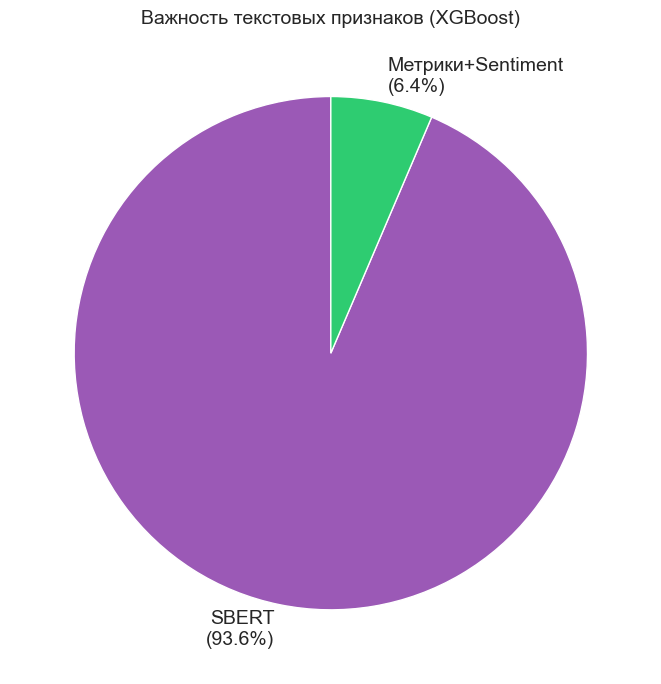

In [17]:
best_text = results_l4[('Text (L4)', best)]['model']
if hasattr(best_text, 'feature_importances_'):
    fi = pd.Series(best_text.feature_importances_, index=text_feature_names)
else:
    fi = pd.Series(np.abs(best_text.coef_), index=text_feature_names)

sbert_imp = fi[sbert_cols].sum()
metrics_imp = fi[list(df_metrics.columns)].sum()
total = sbert_imp + metrics_imp
print(f'SBERT: {sbert_imp/total*100:.1f}%, Метрики+Sentiment: {metrics_imp/total*100:.1f}%')

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie([sbert_imp, metrics_imp],
       labels=[f'SBERT\n({sbert_imp/total*100:.1f}%)', f'Метрики+Sentiment\n({metrics_imp/total*100:.1f}%)'],
       colors=['#9b59b6','#2ecc71'], startangle=90, textprops={'fontsize':14})
ax.set_title(f'Важность текстовых признаков ({best})', fontsize=14)
plt.tight_layout(); plt.show()

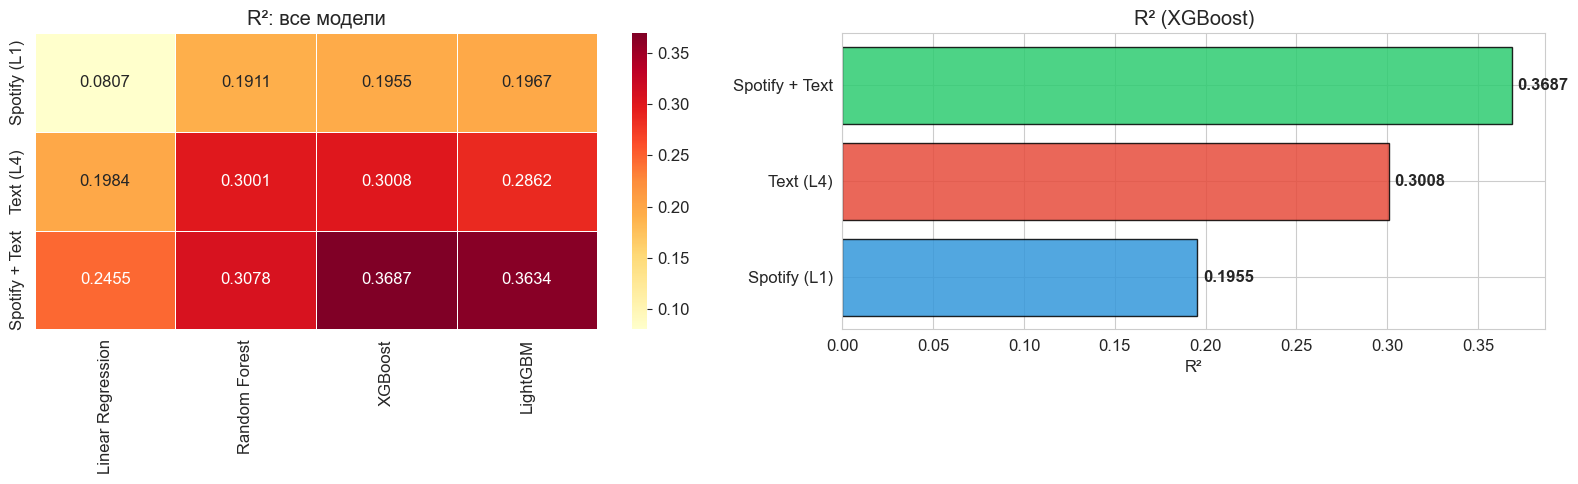

In [18]:
heat = pd.DataFrame({m: [results_l4[(c,m)]['R2'] for c in cnames] for m in mnames}, index=cnames)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(heat, annot=True, fmt='.4f', cmap='YlOrRd', ax=axes[0], linewidths=0.5)
axes[0].set_title('R²: все модели')

r2_vals = [results_l4[(c,best)]['R2'] for c in cnames]
axes[1].barh(cnames, r2_vals, color=['#3498db','#e74c3c','#2ecc71'], edgecolor='black', alpha=0.85)
for i, v in enumerate(r2_vals):
    axes[1].text(v+0.003, i, f'{v:.4f}', va='center', fontweight='bold')
axes[1].set_xlabel('R²'); axes[1].set_title(f'R² ({best})')
plt.tight_layout(); plt.show()

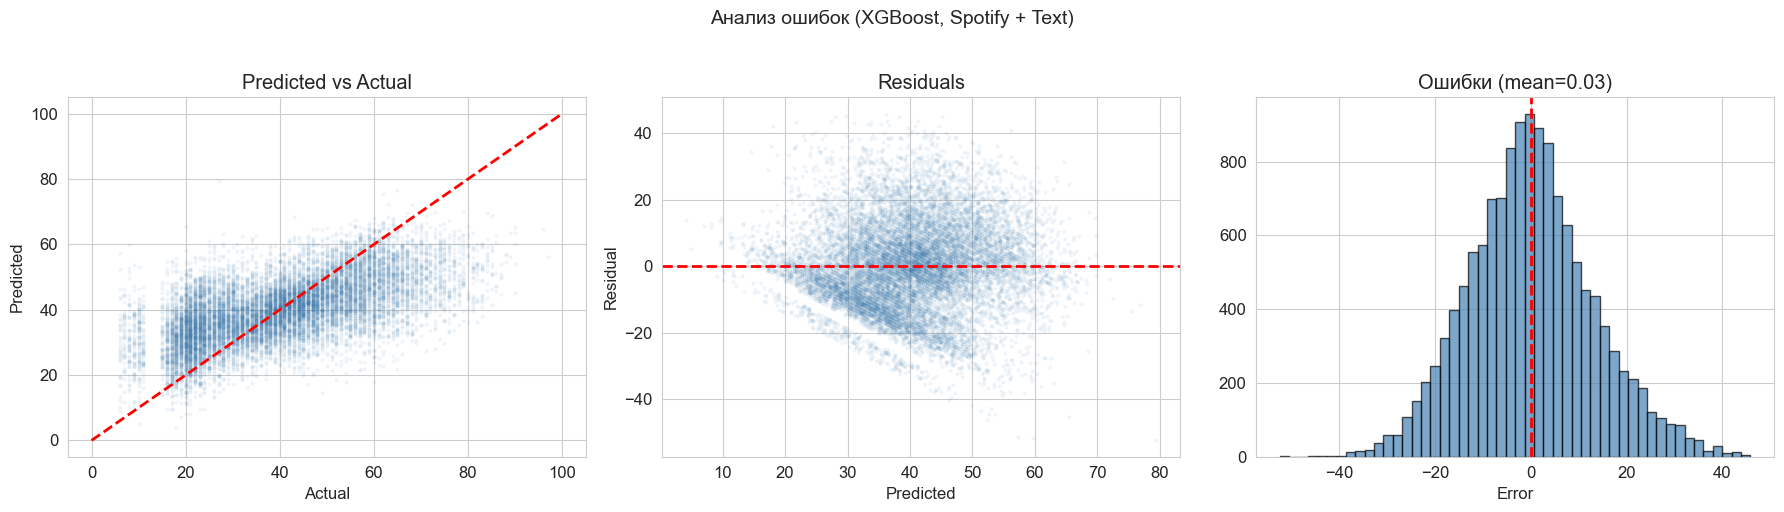

MAE по бинам:
  (5.909, 24.2]       : MAE= 13.30 (n=3,148.0)
  (24.2, 42.4]        : MAE=  6.86 (n=4,605.0)
  (42.4, 60.6]        : MAE=  8.29 (n=4,217.0)
  (60.6, 78.8]        : MAE= 17.92 (n=1,517.0)
  (78.8, 97.0]        : MAE= 30.25 (n=149.0)


In [19]:
yp = results_l4[('Spotify + Text',best)]['y_pred']
yte = y.iloc[te].values; errors = yte - yp
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(yte, yp, alpha=0.05, s=5, c='steelblue')
axes[0].plot([0,100],[0,100], 'r--', lw=2)
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted'); axes[0].set_title('Predicted vs Actual')
axes[1].scatter(yp, errors, alpha=0.05, s=5, c='steelblue')
axes[1].axhline(0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Residual'); axes[1].set_title('Residuals')
axes[2].hist(errors, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[2].axvline(0, color='r', linestyle='--', lw=2)
axes[2].set_xlabel('Error'); axes[2].set_title(f'Ошибки (mean={np.mean(errors):.2f})')
plt.suptitle(f'Анализ ошибок ({best}, Spotify + Text)', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

bins_p = pd.cut(yte, bins=5)
df_err = pd.DataFrame({'actual':yte,'predicted':yp,'abs_error':np.abs(errors),'bin':bins_p})
print('MAE по бинам:')
for idx_b, row in df_err.groupby('bin')['abs_error'].agg(['mean','count']).iterrows():
    print(f'  {str(idx_b):20s}: MAE={row["mean"]:6.2f} (n={row["count"]:,})')

---
## 6. Выводы

In [20]:
r2_sp = results_l4[('Spotify (L1)',best)]['R2']
r2_text = results_l4[('Text (L4)',best)]['R2']
r2_both = results_l4[('Spotify + Text',best)]['R2']

print('='*60)
print(f'ВЫВОДЫ ПО УРОВНЮ 4 ({best})')
print('='*60)
print(f'''
1. ДАННЫЕ:
   Источник: Genius API
   Найдено лирики: {len(df_text):,}/{len(df):,} ({len(df_text)/len(df)*100:.1f}%)
   Текстовых признаков: {len(text_feature_names)} (SBERT: {sbert_embeddings.shape[1]}, Sentiment: 4, Метрики: 9)

2. РЕЗУЛЬТАТЫ ({best}):
   Spotify (14 фичей):    R² = {r2_sp:.4f}
   Text ({len(text_feature_names)} фичей):      R² = {r2_text:.4f}
   Spotify + Text:        R² = {r2_both:.4f}

3. ВКЛАД ТЕКСТА:
   Δ R² (Text vs Spotify): {r2_text-r2_sp:+.4f}
   → Текст — более сильный предиктор чем аудио-фичи Spotify

4. ВАЖНОСТЬ:
   SBERT: {sbert_imp/total*100:.1f}%, Метрики+Sentiment: {metrics_imp/total*100:.1f}%
   → Семантика (SBERT) доминирует
''')

res_list = []
for (c,m),r in results_l4.items():
    res_list.append({'Config':c,'Model':m,'R2':round(r['R2'],4),'MAE':round(r['MAE'],3),'RMSE':round(r['RMSE'],3),'AUC':round(r['AUC'],4)})
pd.DataFrame(res_list).to_csv('level4_results.csv', index=False)
print('Сохранено: level4_results.csv, text_features.csv, genius_lyrics_cache.json')

ВЫВОДЫ ПО УРОВНЮ 4 (XGBoost)

1. ДАННЫЕ:
   Источник: Genius API
   Найдено лирики: 68,176/81,207 (84.0%)
   Текстовых признаков: 397 (SBERT: 384, Sentiment: 4, Метрики: 9)

2. РЕЗУЛЬТАТЫ (XGBoost):
   Spotify (14 фичей):    R² = 0.1955
   Text (397 фичей):      R² = 0.3008
   Spotify + Text:        R² = 0.3687

3. ВКЛАД ТЕКСТА:
   Δ R² (Text vs Spotify): +0.1052
   → Текст — более сильный предиктор чем аудио-фичи Spotify

4. ВАЖНОСТЬ:
   SBERT: 93.6%, Метрики+Sentiment: 6.4%
   → Семантика (SBERT) доминирует

Сохранено: level4_results.csv, text_features.csv, genius_lyrics_cache.json
